# Assignment 4: Numerical Analysis for PDE's (WI3730TU)
### Numerical Solution of Time-Dependent Problems

## 📐 Section 1: Estimating the Maximal Eigenvalue 

While determining the stability condition for a time-integration method it is important to know the ``largest'' eigenvalue of some matrix $A$. Often, for example, when the coefficient function is inhomogeneous, the largest eigenvalue cannot be obtained analytically. In such cases, it is possible to estimate the location of the eigenvalues of $A$ approximately using the following Lemma.

**Lemma (Gerschgorin):**
*Let $A\in{\mathbb C}^{n\times n}$ be an an arbitrary square matrix with elements $a_{r,m}$. Then all eigenvalues of $A$ are contained in the union of $n$ discs ${\mathbb D}_{r}$, $r=1,\dots,n$:*
$${\mathbb D}_{r}=\left\{
z\in{\mathbb C}\;:\;\vert z-a_{r,r}\vert\leq \sum_{m\neq r}^{n}\vert a_{r,m}\vert
\right\}.
$$

In other words, the Gerschgorin's disc ${\mathbb D}_{r}$ represents a circle in the complex plane. The center of ${\mathbb D}_{r}$ is $a_{r,r}$, i.e., the complex number equal to the diagonal element of the $r$-th row of $A$. The radius of ${\mathbb D}_{r}$ is equal to the sum of the absolute values of all off-diagonal elements of the $r$-th row of $A$. There are as many Gerschgorin discs as there are rows in $A$ and all eigenvalues of $A$ are located somewhere inside the union of all these discs.

---

### Question 1.1: Diagonal and off-diagonal elements of FVM Laplacian (2 p)
Let $A$ be the matrix obtained by the Finite-Volume discretization of the two-dimensional Laplace operator $-\nabla\cdot(k\nabla\cdots)$ with an inhomogeneous coefficient function $k(x,y)$ and Dirichlet boundary conditions. Write down the diagonal and off-diagonal elements along some row of the matrix $A$.

---
For an interior grid point $(x_i,y_j)$, let

$$
k_E=k\left(x_i+\frac{\Delta x}{2},y_j\right),\qquad
k_W=k\left(x_i-\frac{\Delta x}{2},y_j\right),
$$

$$
k_N=k\left(x_i,y_j+\frac{\Delta y}{2}\right),\qquad
k_S=k\left(x_i,y_j-\frac{\Delta y}{2}\right).
$$

The diagonal element in the corresponding row of the FVM matrix $A$ for some row $i$ is

$$
A_{ii}
=
\frac{k_W+k_E}{\Delta x^2}
+
\frac{k_S+k_N}{\Delta y^2}
$$

and the four possible off-diagonal elements are

$$
A_{i,i-1}=-\frac{k_W}{\Delta x^2},\qquad
A_{i,i+1}=-\frac{k_E}{\Delta x^2}
$$

and

$$
A_{i,i-(N_x-1)}=-\frac{k_S}{\Delta y^2},\qquad
A_{i,i+(N_x-1)}=-\frac{k_N}{\Delta y^2}.
$$

Thus, the diagonal entry is positive and equals the sum of the absolute values of the four neighboring coefficients, while all nonzero off-diagonal entries are negative. For points adjacent to a Dirichlet boundary, the corresponding boundary value is not an unknown, so that off-diagonal matrix entry is absent, while its coefficient remains included in the diagonal term.

### Question 1.2: Upper bound on maximal eigenvalue of FVM Laplacian (3 p)
Use the fact that $A$ is symmetric and positive defnite and Gerschgorin's Lemma to determine an upper bound on the largest eigenvalue of $A$.

---
Because $A$ is symmetric, all of its eigenvalues are real. Because $A$ is also positive definite, all eigenvalues satisfy

$$
\lambda_i>0.
$$

For row $i$, Gerschgorin's Lemma states that every eigenvalue $\lambda$ belonging to the union of the Gerschgorin discs satisfies

$$
|\lambda-A_{i,i}|\leq R_i,
$$

where

$$
R_i=\sum_{j\neq i}|A_{i,j}|
$$

is the sum of the absolute values of the off-diagonal entries in that row.

From Question 1.1, for an interior grid point,

$$
A_{i,i}
=
\frac{k_W+k_E}{\Delta x^2}
+
\frac{k_S+k_N}{\Delta y^2},
$$

while the four off-diagonal coefficients are

$$
-\frac{k_W}{\Delta x^2},\qquad
-\frac{k_E}{\Delta x^2},\qquad
-\frac{k_S}{\Delta y^2},\qquad
-\frac{k_N}{\Delta y^2}.
$$

Therefore, for a full interior row,

$$
R_i
=
\frac{k_W+k_E}{\Delta x^2}
+
\frac{k_S+k_N}{\Delta y^2}
=
A_{i,i}.
$$

Hence its Gerschgorin disc is

$$
|\lambda-A_{i,i}|\leq A_{i,i}.
$$

Since the eigenvalues are real, this disc corresponds to the real interval

$$
0\leq\lambda\leq 2A_{i,i}.
$$

For rows adjacent to a Dirichlet boundary, one or more neighbouring values are prescribed and therefore do not appear as unknowns in the matrix. In those rows the off-diagonal sum is smaller, so

$$
R_i\leq A_{i,i}.
$$

Consequently, the same upper bound remains valid for every row:

$$
\lambda
\leq
A_{i,i}+R_i
\leq
2A_{i,i}.
$$

Taking the maximum over all rows gives

$$
\lambda_{\max}(A)
\leq
2\max_i A_{i,i}.
$$

Now define

$$
k_{\max}=\max_{(x,y)\in\Omega}k(x,y).
$$

Since each face coefficient satisfies

$$
k_W,k_E,k_S,k_N\leq k_{\max},
$$

the diagonal entry can be bounded by

$$
A_{i,i}
=
\frac{k_W+k_E}{\Delta x^2}
+
\frac{k_S+k_N}{\Delta y^2}
\leq
\frac{2k_{\max}}{\Delta x^2}
+
\frac{2k_{\max}}{\Delta y^2}.
$$

Therefore,

$$
\lambda_{\max}(A)
\leq
4k_{\max}
\left(
\frac{1}{\Delta x^2}
+
\frac{1}{\Delta y^2}
\right)
$$

is an upper bound on the largest eigenvalue of the FVM matrix.


## 📐 Section 2: Numerical Solution of Diffusion Equation

Consider the following problem:
$$
\frac{\partial u}{\partial t}-\nabla\cdot(k\nabla u)  = f,\;\;\;(x,y)\in\Omega,\;\;\;t\in(0,T],
$$
$$
u(x,y,t)  = 0,\;\;\;(x,y)\in\partial\Omega
$$
$$
u(x,y,0)  = 0,\;\;\;(x,y)\in\Omega
$$
$$
k(x,y) = 4+2\cos\left(\frac{2\pi x}{L_{x}}\right)\sin\left(\frac{2\pi y}{L_{y}}\right)
$$
The function
$$
u_{ex}(x,y,t)  = t^{3} \sin\left(\frac{3\pi x}{L_{x}}\right)\sin\left(\frac{2\pi y}{L_{y}}\right)
$$
will be the exact solution if the source function in the diffusion equation is *manufactured* as:
$$
f_{ms}=\frac{\partial u_{ex}}{\partial t}-\nabla\cdot(k\nabla u_{ex})=2t^{2} \sin\left(\frac{3\pi x}{L_{x}}\right)\sin\left(\frac{2\pi y}{L_{y}}\right)-\nabla\cdot(k\nabla u_{ex}).
$$

### Question 2.1: Spatial discretization and time integration (2 p)
After applying the Finite Volume Method to descretize the problem in space it reduces to the following system of ordinary differential equations:
$$
{\mathbf u}' = -A{\mathbf u}+{\mathbf f},
$$
where $A$ is the matrix containing the FV approximation of the negative Laplacian operator derived in Assignment 3.

Write down the recurrence formulas (iteration formulas) of the Forward-Euler and Trapesoidal Methods for your problem, denoting the solution at $t_{k}$ as ${\mathbf u}^{k}$.



---
For the spatially discretized problem,

$$
\mathbf{u}'(t)=-A\mathbf{u}(t)+\mathbf{f}(t),
$$

define the time levels by

$$
t_k=k\Delta t,
\qquad
\mathbf{u}^k\approx\mathbf{u}(t_k),
\qquad
\mathbf{f}^k=\mathbf{f}(t_k).
$$

At node $(i,j)$,

$$
u_{i,j}^k\approx u(x_i,y_j,t_k).
$$

Using the FVM stencil from Question 1.1,

$$
(A\mathbf{u}^k)_{i,j}
=
\left(
\frac{k_W+k_E}{\Delta x^2}
+
\frac{k_S+k_N}{\Delta y^2}
\right)u_{i,j}^k
-\frac{k_W}{\Delta x^2}u_{i-1,j}^k
-\frac{k_E}{\Delta x^2}u_{i+1,j}^k
-\frac{k_S}{\Delta y^2}u_{i,j-1}^k
-\frac{k_N}{\Delta y^2}u_{i,j+1}^k.
$$

Therefore, the semi-discrete equation at node $(i,j)$ is

$$
\frac{d u_{i,j}}{dt}
=
-\left(
\frac{k_W+k_E}{\Delta x^2}
+
\frac{k_S+k_N}{\Delta y^2}
\right)u_{i,j}
+\frac{k_W}{\Delta x^2}u_{i-1,j}
+\frac{k_E}{\Delta x^2}u_{i+1,j}
+\frac{k_S}{\Delta y^2}u_{i,j-1}
+\frac{k_N}{\Delta y^2}u_{i,j+1}
+f_{i,j}(t).
$$

For the **Forward-Euler method**,

$$
\frac{\mathbf{u}^{k+1}-\mathbf{u}^{k}}{\Delta t}
=
-A\mathbf{u}^{k}+\mathbf{f}^{k}.
$$

Hence,

$$
\mathbf{u}^{k+1}
=
\left(I-\Delta t A\right)\mathbf{u}^{k}
+
\Delta t\,\mathbf{f}^{k}
$$

or equivalently,

$$
\mathbf{u}^{k+1}
=
\mathbf{u}^{k}
+
\Delta t\left(-A\mathbf{u}^{k}+\mathbf{f}^{k}\right).
$$

At node $(i,j)$,

$$
\begin{aligned}
u_{i,j}^{k+1}
={}&u_{i,j}^{k}
+\Delta t
\Bigg[
-\left(
\frac{k_W+k_E}{\Delta x^2}
+
\frac{k_S+k_N}{\Delta y^2}
\right)u_{i,j}^{k} \\
&+\frac{k_W}{\Delta x^2}u_{i-1,j}^{k}
+\frac{k_E}{\Delta x^2}u_{i+1,j}^{k}
+\frac{k_S}{\Delta y^2}u_{i,j-1}^{k}
+\frac{k_N}{\Delta y^2}u_{i,j+1}^{k}
+f_{i,j}^{k}
\Bigg].
\end{aligned}
$$

All quantities on the right-hand side are known at time $t_k$, so Forward Euler is an **explicit** method.

For the **Trapezoidal method**,

$$
\frac{\mathbf{u}^{k+1}-\mathbf{u}^{k}}{\Delta t}
=
\frac{1}{2}
\left[
\left(-A\mathbf{u}^{k}+\mathbf{f}^{k}\right)
+
\left(-A\mathbf{u}^{k+1}+\mathbf{f}^{k+1}\right)
\right].
$$

Rearranging all terms containing $\mathbf{u}^{k+1}$ to the left gives

$$
\left(I+\frac{\Delta t}{2}A\right)\mathbf{u}^{k+1}
=
\left(I-\frac{\Delta t}{2}A\right)\mathbf{u}^{k}
+
\frac{\Delta t}{2}
\left(\mathbf{f}^{k}+\mathbf{f}^{k+1}\right).
$$

At node $(i,j)$, before rearranging,

$$
\begin{aligned}
u_{i,j}^{k+1}
={}&u_{i,j}^{k}
+\frac{\Delta t}{2}
\Bigg[
-\left(
\frac{k_W+k_E}{\Delta x^2}
+
\frac{k_S+k_N}{\Delta y^2}
\right)
\left(u_{i,j}^{k}+u_{i,j}^{k+1}\right) \\
&+\frac{k_W}{\Delta x^2}
\left(u_{i-1,j}^{k}+u_{i-1,j}^{k+1}\right)
+\frac{k_E}{\Delta x^2}
\left(u_{i+1,j}^{k}+u_{i+1,j}^{k+1}\right) \\
&+\frac{k_S}{\Delta y^2}
\left(u_{i,j-1}^{k}+u_{i,j-1}^{k+1}\right)
+\frac{k_N}{\Delta y^2}
\left(u_{i,j+1}^{k}+u_{i,j+1}^{k+1}\right) \\
&+f_{i,j}^{k}+f_{i,j}^{k+1}
\Bigg].
\end{aligned}
$$

Because values at time $t_{k+1}$ appear in the equation, the Trapezoidal method is **implicit**. A linear system must therefore be solved at each time step.


### Question 2.2: Stability condition for the Forward-Euler Method (2 p)
Derive the stability condition for the FE method with the FVM discretization and inhomogeneous $k(x,y)$, using the bounds on the largest eigenvalue of $A$ obtained in Question 1.2. Express the stability condition as a minimum number of time steps between $t=0$ and $t=T$.

For the Forward-Euler method,

$$
\mathbf{u}^{k+1}
=
\left(I-\Delta t A\right)\mathbf{u}^{k}
+
\Delta t\,\mathbf{f}^{k}.
$$

The source term does not affect the linear stability condition. Since $A$ is symmetric positive definite, all its eigenvalues $\lambda_i$ are real and positive. For an eigenmode corresponding to $\lambda_i$, the Forward-Euler amplification factor is

$$
G_i=1-\Delta t\,\lambda_i.
$$

Stability requires $|G_i|\leq 1,$ so

$$
|1-\Delta t\,\lambda_i|\leq 1.
$$

Because $$\lambda_i>0$$, this gives

$$
0\leq \Delta t\,\lambda_i\leq 2.
$$

The most restrictive condition is therefore determined by the largest eigenvalue:

$$
\Delta t\leq\frac{2}{\lambda_{\max}(A)}.
$$

From Question 1.2, Gerschgorin's Lemma gives

$$
\lambda_{\max}(A)
\leq
2\max_{i,j} a_{(i,j),(i,j)},
$$

For

$$
k(x,y)
=
4+2\cos\left(\frac{2\pi x}{L_x}\right)
\sin\left(\frac{2\pi y}{L_y}\right),
$$

we have $2\leq k(x,y)\leq 6,$ and therefore $k_{\max}=6.$ Using the bound obtained in Question 1.2,

$$
\lambda_{\max}(A)
\leq
4k_{\max}
\left(
\frac{1}{\Delta x^2}
+
\frac{1}{\Delta y^2}
\right)
=
24
\left(
\frac{1}{\Delta x^2}
+
\frac{1}{\Delta y^2}
\right).
$$

Thus a sufficient Forward-Euler stability condition is

$$
\Delta t
\leq
\frac{1}
{
12\left(
\frac{1}{\Delta x^2}
+
\frac{1}{\Delta y^2}
\right)
}.
$$

If $N_t$ equally sized time steps are used between $t=0$ and $t=T$, then

$$
\Delta t=\frac{T}{N_t}.
$$

Therefore,

$$
\frac{T}{N_t}
\leq
\frac{1}
{
12\left(
\frac{1}{\Delta x^2}
+
\frac{1}{\Delta y^2}
\right)
},
$$

which gives the minimum number of time steps

$$
N_t
\geq
12T
\left(
\frac{1}{\Delta x^2}
+
\frac{1}{\Delta y^2}
\right).
$$

Since $N_t$ must be an integer, one can choose

$$
N_t
=
\left\lceil
12T
\left(
\frac{1}{\Delta x^2}
+
\frac{1}{\Delta y^2}
\right)
\right\rceil.
$$

### 📊 Question 2.3: Implementation of FVM Laplacian, source, and coefficient functions (2 p)

Complete the code to assemble FVM Laplacian matrix, source function and vector, and coefficient function.

---

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as la
import time

#----- Parameters -------------------------------------------------------------#
Lx = 10.0  # x-size of the domain
Ly = 5.0   # y-size of the domain
Nx = 100   # number of intervals in x-direction
Ny = 50    # number of intervals in y-direction
dx = Lx / Nx
dy = Ly / Ny
T  = 1.0   # total final integration time

# Upper bound bound coefficient parameter for Forward-Euler stability limit calculation
Kmax = 6.0 

#----- Manufactured Solution Framework Functions ------------------------------#

def u_exact(x, y, t, Lx=Lx, Ly=Ly):
    '''
    Exact manufactured solution:
    u_ex(x,y,t) = t^3 sin(3*pi*x/Lx) sin(2*pi*y/Ly)
    '''
    u_val = (t**3) * np.sin(3 * np.pi * x / Lx) * \
                     np.sin(2 * np.pi * y / Ly)
    return u_val



def du_dt(x, y, t, Lx=Lx, Ly=Ly):
    '''
    Time derivative of the manufactured solution:
    du_ex/dt = 3 t^2 sin(3*pi*x/Lx) sin(2*pi*y/Ly)
    '''
    derivative_val = 3.0 * (t**2) * \
                     np.sin(3 * np.pi * x / Lx) * \
                     np.sin(2 * np.pi * y / Ly)
    return derivative_val



def coeffK(x, y, Lx=Lx, Ly=Ly):
    '''
    Variable diffusion coefficient:
    k(x,y) = 4 + 2 cos(2*pi*x/Lx) sin(2*pi*y/Ly)
    '''
    k_val = 4.0 + 2.0 * \
            np.cos(2 * np.pi * x / Lx) * \
            np.sin(2 * np.pi * y / Ly)
    return k_val


def create_f_mms_vector(t, A_matrix, Lx=Lx, Ly=Ly, Nx=Nx, Ny=Ny):
    '''
    Manufactured RHS:
        f_mms = du/dt + A*u

    because A discretizes -div(k grad u).
    '''
    dx = Lx / Nx
    dy = Ly / Ny
    N_inner = (Nx - 1) * (Ny - 1)

    du_dt_vec = np.zeros(N_inner)
    u_exact_vec = np.zeros(N_inner)

    # Lexicographic ordering: x varies fastest
    n0 = 0

    for jj in range(Ny - 1):
        yj = dy + jj * dy

        for ii in range(Nx - 1):
            xi = dx + ii * dx

            du_dt_vec[n0] = du_dt(xi, yj, t, Lx, Ly)
            u_exact_vec[n0] = u_exact(xi, yj, t, Lx, Ly)

            n0 += 1

    f_mms_vec = du_dt_vec + A_matrix.dot(u_exact_vec)

    return f_mms_vec

#----- 2D Finite Volume negative Laplacian Matrix Assembly (DON'T MODIFY) -----#

def create2DLFVM(Lx, Ly, Nx, Ny, coeffFun):
    '''Creates the sparse CSC matrix representing the 2D FVM negative Laplacian 
    with variable coefficients (Dirichlet BCs, lexicographic grid order).
    '''
    dx = Lx / Nx
    dy = Ly / Ny
    N_inner = (Nx - 1) * (Ny - 1)

    # Allocating 1D arrays for the tridiagonal structure
    d0 = np.zeros(N_inner)
    d1plus = np.zeros(N_inner - 1)
    d1minus = np.zeros(N_inner - 1)
    d2plus = np.zeros(N_inner - (Nx - 1))
    d2minus = np.zeros(N_inner - (Nx - 1))

    n0, n1p, n1m, n2p, n2m = 0, 0, 0, 0, 0
    
    for jj in range(Ny - 1):
        yj = dy + jj * dy
        for ii in range(Nx - 1):
            xi = dx + ii * dx

            # Main diagonal
            d0[n0] = ( coeffFun(xi - 0.5*dx, yj)/dx**2 + coeffFun(xi + 0.5*dx, yj)/dx**2
                      + coeffFun(xi, yj - 0.5*dy)/dy**2 + coeffFun(xi, yj + 0.5*dy)/dy**2 )
            n0 += 1

            # 1st upper diagonal
            if (ii < (Nx - 2)):
                d1plus[n1p] = -coeffFun(xi + 0.5*dx, yj) / dx**2
                n1p += 1
            elif (ii == (Nx - 2)):
                n1p += 1

            # 1st lower diagonal
            if (ii > 0):
                d1minus[n1m] = -coeffFun(xi - 0.5*dx, yj) / dx**2
                n1m += 1
            elif (ii == 0 and jj > 0):
                n1m += 1

            # 2nd upper diagonal
            if (jj < (Ny - 2)):
                d2plus[n2p] = -coeffFun(xi, yj + 0.5*dy) / dy**2
                n2p += 1

            # 2nd lower diagonal
            if (jj > 0):
                d2minus[n2m] = -coeffFun(xi, yj - 0.5*dy) / dy**2
                n2m += 1

    myshape = (N_inner, N_inner)
    L = sp.diags([d2minus, d1minus, d0, d1plus, d2plus],
                 [-(Nx - 1), -1, 0, 1, (Nx - 1)],
                 shape=myshape, format='csc')
    return L


### 📊 Question 2.4: Constructing the manufactured solution (2 p)

Complete the code to plot the coefficient function $k(x,y)$, the manufactured source function $f(x,y,t)$ at $t=1$, and the exact solution $u_{ex}(x,y,t)$ at $t=1$.

---


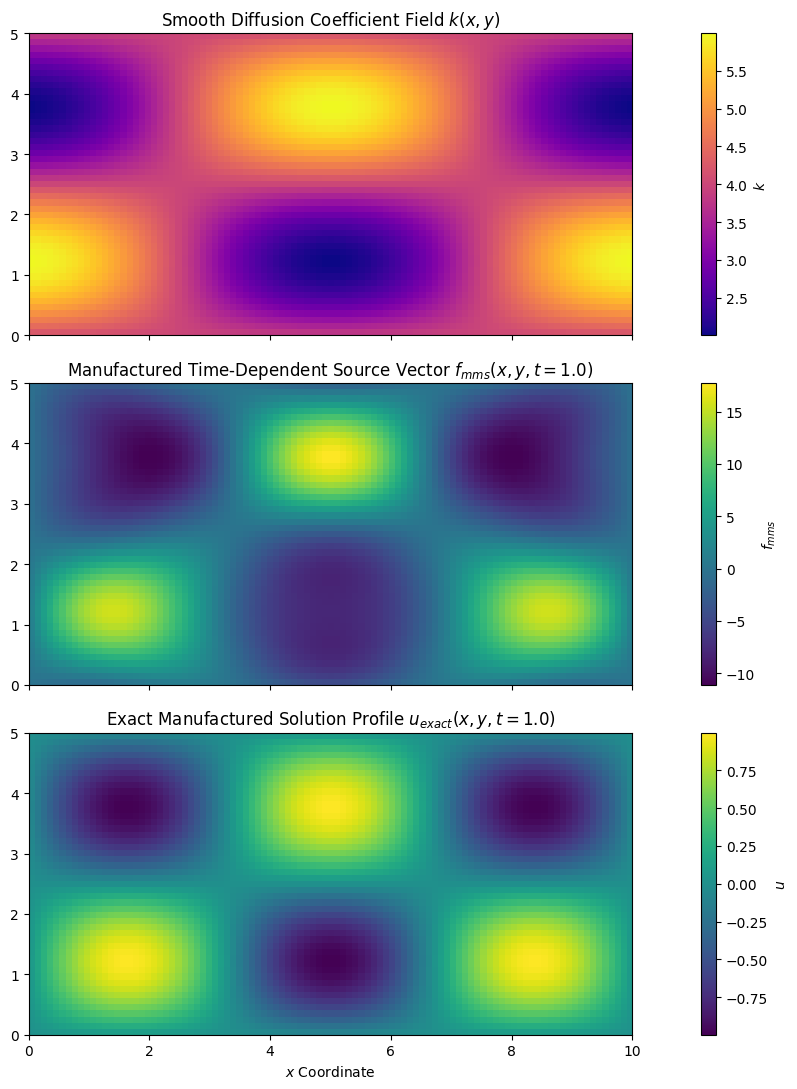

In [3]:
# 1. Evaluate fields on the grid
X = np.linspace(dx, Lx - dx, Nx - 1)
Y = np.linspace(dy, Ly - dy, Ny - 1)
X_grid, Y_grid = np.meshgrid(X, Y)

k_grid = coeffK(X_grid, Y_grid)
u_exact_grid = u_exact(X_grid, Y_grid, t=1.0)

# Build sparse FVM matrix and MMS source vector
A_matrix = create2DLFVM(Lx, Ly, Nx, Ny, coeffK)

f_mms_T1 = create_f_mms_vector(1.0, A_matrix)
f_mms_grid = f_mms_T1.reshape(Ny - 1, Nx - 1)

# 2. Plotting
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

im0 = axes[0].imshow(
    k_grid,
    extent=[0, Lx, 0, Ly],
    origin='lower',
    cmap='plasma'
)
axes[0].set_title('Smooth Diffusion Coefficient Field $k(x,y)$')
fig.colorbar(im0, ax=axes[0], label='$k$')

im1 = axes[1].imshow(
    f_mms_grid,
    extent=[0, Lx, 0, Ly],
    origin='lower',
    cmap='viridis'
)
axes[1].set_title(
    'Manufactured Time-Dependent Source Vector $f_{mms}(x,y,t=1.0)$'
)
fig.colorbar(im1, ax=axes[1], label='$f_{mms}$')

im2 = axes[2].imshow(
    u_exact_grid,
    extent=[0, Lx, 0, Ly],
    origin='lower',
    cmap='viridis'
)
axes[2].set_title(
    'Exact Manufactured Solution Profile $u_{exact}(x,y,t=1.0)$'
)
fig.colorbar(im2, ax=axes[2], label='$u$')

axes[2].set_xlabel('$x$ Coordinate')

plt.tight_layout()
plt.show()

### 📊 Question 2.5: Implementing of Forward-Euler and Trapezoidal time-integration methods (3 p)

Complete the code to implement the Forward-Euler and the Trapezoidal iterations, assuming the source function is time-dependent.

---

In [3]:
# Create shared matrix operators
A = create2DLFVM(Lx, Ly, Nx, Ny, coeffK)
I = sp.eye((Nx - 1) * (Ny - 1))

def solveFE_mms(uStart, tStart=0.0, tEnd=T, Nt=1, A=A, I=I):
    '''
    TASK: Implement the explicit Forward-Euler method over time loops.
    Recurrence formula: u^{k+1} = u^{k} + dt * (-A * u^{k} + f^{k})
    '''
    dt = (tEnd - tStart) / Nt
    u1 = np.copy(uStart)
    uEnd = np.copy(uStart)
    for k in range(Nt):
        t_current = tStart + k * dt

        f_vec = create_f_mms_vector(t_current, A)

        uEnd = (I - dt * A).dot(u1) + dt * f_vec

        u1 = np.copy(uEnd)
    return uEnd

def solveTR_mms(uStart, tStart=0.0, tEnd=T, Nt=1, A=A, I=I):
    '''
    Implicit Trapezoidal method:
    [I + (dt/2)A] u^{k+1}
    =
    [I - (dt/2)A] u^k
    + (dt/2)(f^k + f^{k+1})
    '''
    dt = (tEnd - tStart) / Nt
    u1 = np.copy(uStart)
    uEnd = np.copy(uStart)

    # Matrices do not change with time, so construct them once
    iterMat1 = I - 0.5 * dt * A
    iterMat2 = sp.csc_matrix(I + 0.5 * dt * A)

    # Factorize the implicit matrix once
    LU_solver = la.splu(iterMat2)

    for k in range(Nt):
        t_k = tStart + k * dt
        t_k1 = t_k + dt

        # Source at both endpoints of the time interval
        f_k = create_f_mms_vector(t_k, A)
        f_k1 = create_f_mms_vector(t_k1, A)

        # Right-hand side
        uInter = (
            iterMat1.dot(u1)
            + 0.5 * dt * (f_k + f_k1)
        )

        # Solve for u^{k+1}
        uEnd = LU_solver.solve(uInter)

        # Move to next time step
        u1 = np.copy(uEnd)

    return uEnd

### Question 2.6: Running FE method at the stability bound (2 p)

Complete the code to compute the solution at $t=1$ using the FE Method with the number of time steps corresponding to its stability bound

---


---------------------------------------------------------------------
Executing Forward-Euler at the stability limit to compute u(x,y,T=1.0)
-> Mesh step sizes: dx = 0.1000, dy = 0.1000
-> Maximum stable dt bound:  0.00041667
-> Chosen stable parameters: Nt = 2400 ; dt = 0.00041667
---------------------------------------------------------------------
Forward-Euler execution complete.
Execution Time (tCPU): 0.0002 seconds
Max Absolute Truncation Error (L_inf) vs. Exact Solution: 1.000000e+00
---------------------------------------------------------------------


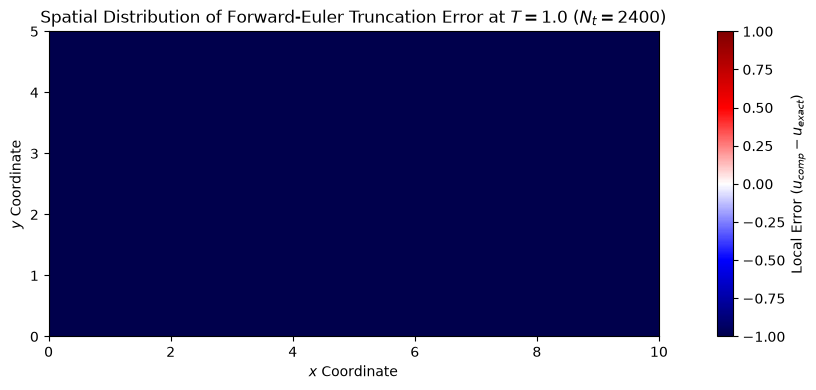

In [9]:
# Define initial condition array (u = 0 everywhere at t = 0)
u0arr = np.zeros((Ny-1)*(Nx-1))
u0 = u0arr.reshape((Nx-1)*(Ny-1))

# Final simulation time
T_test = 1.0

print("---------------------------------------------------------------------")
print(f"Executing Forward-Euler at the stability limit to compute u(x,y,T={T_test})")

# 1. Dynamically compute the maximum stable time-step size using k_max = 6.0
dt_theoretical_max = 1.0 / (2.0 * (1.0/dx**2 + 1.0/dy**2) * Kmax)

# Calculate the minimum required stable steps (using ceiling to be safe)
NtFE = int(np.ceil(T_test / dt_theoretical_max))
dtFE = T_test / NtFE

print(f"-> Mesh step sizes: dx = {dx:.4f}, dy = {dy:.4f}")
print(f"-> Maximum stable dt bound:  {dt_theoretical_max:.8f}")
print(f"-> Chosen stable parameters: Nt = {NtFE} ; dt = {dtFE:.8f}")
print("---------------------------------------------------------------------")

# 2. Run the Forward-Euler solver and track CPU time
start_clock = time.time()
uFE = solveFE_mms(u0, tStart=0.0, tEnd=T_test, Nt=NtFE)
CPUtimeFE = time.time() - start_clock

print(f"Forward-Euler execution complete.")
print(f"Execution Time (tCPU): {CPUtimeFE:.4f} seconds")

# 3. Compute the exact analytical solution matrix at T = 1.0 for verification
u_exact_T1 = np.zeros((Ny-1)*(Nx-1))
n0 = 0
for jj in range(Ny-1):
    yj = dy + jj*dy
    for ii in range(Nx-1):
        xi = dx + ii*dx
        u_exact_T1[n0] = u_exact(xi, yj, T_test)
        n0 += 1

# 4. Compute global Max Absolute Error (L_infinity norm)
max_error_FE = np.max(np.abs(uFE - u_exact_T1))
print(f"Max Absolute Truncation Error (L_inf) vs. Exact Solution: {max_error_FE:.6e}")
print("---------------------------------------------------------------------")

# 5. Visualize the numerical error field spatially
fig, ax = plt.subplots(figsize=(12, 4))
error_grid_FE = (uFE - u_exact_T1).reshape(Ny-1, Nx-1)

im = ax.imshow(error_grid_FE, extent=[0, Lx, 0, Ly], origin='lower', cmap='seismic', 
               vmin=-max(1e-10, np.max(np.abs(error_grid_FE))), vmax=max(1e-10, np.max(np.abs(error_grid_FE))))
ax.set_title(f'Spatial Distribution of Forward-Euler Truncation Error at $T={T_test}$ ($N_t={NtFE}$)', fontsize=12)
ax.set_xlabel('$x$ Coordinate')
ax.set_ylabel('$y$ Coordinate')
fig.colorbar(im, ax=ax, label='Local Error ($u_{comp} - u_{exact}$)')
plt.tight_layout()
plt.show()


### Question 2.7: Comparing convergence and performance of FE and Trapezoidal methods (4 p)

Complete the code to run a comparison of the FE and Trapezoidal methods computing the solution of the problem at $t=1$ with diferent number of time steps. 

* For the FE method, compute the solution with $N_{st}$, $2N_{st}$, and $4N_{st}$ time steps, where $N_{st}$ is the lower stability bound.
* For the Trapezoidal method, compute the solution with $N_{st}/40$, $N_{st}/20$, and $N_{st}/10$ time steps.
* For each computed solution, calculate the $L_{\infty}$ global error with respect to the exact manufactured solution $u_{ex}(x,y,t=1)$, i.e., $\epsilon = \max_{x,y}\vert u(x,y,t=1)-u_{ex}(x,y,t=1)\vert$
* For ecah computed solution, record the CPU execution time in seconds
* Visualize the error behavior for both methods in log-log (error as a function of $\Delta t$) plot, together with the expected theoretical convergence, calculate the slopes of your empirical curves
* Visualize the CPU execution time as a function of global error.

---


---------------------------------------------------------------------
Starting Performance Sweep: Accuracy vs. Computational Cost...
---------------------------------------------------------------------
Running Explicit Forward-Euler Sweep...
FE | Nt =  2400 | dt = 0.000417 | Error = 1.000000e+00 | CPU Time = 0.0002s
FE | Nt =  4800 | dt = 0.000208 | Error = 1.000000e+00 | CPU Time = 0.0000s
FE | Nt =  9600 | dt = 0.000104 | Error = 1.000000e+00 | CPU Time = 0.0000s
---------------------------------------------------------------------
Running Implicit Trapezoidal Sweep...
TR | Nt =   240 | dt = 0.004167 | Error = 1.000000e+00 | CPU Time = 0.0000s
TR | Nt =   120 | dt = 0.008333 | Error = 1.000000e+00 | CPU Time = 0.0001s
TR | Nt =    60 | dt = 0.016667 | Error = 1.000000e+00 | CPU Time = 0.0001s
---------------------------------------------------------------------
Empirical Order of Accuracy for Forward Euler: -0.00 (Expected: ~1.0)
Empirical Order of Accuracy for Trapezoidal:   0.00 (

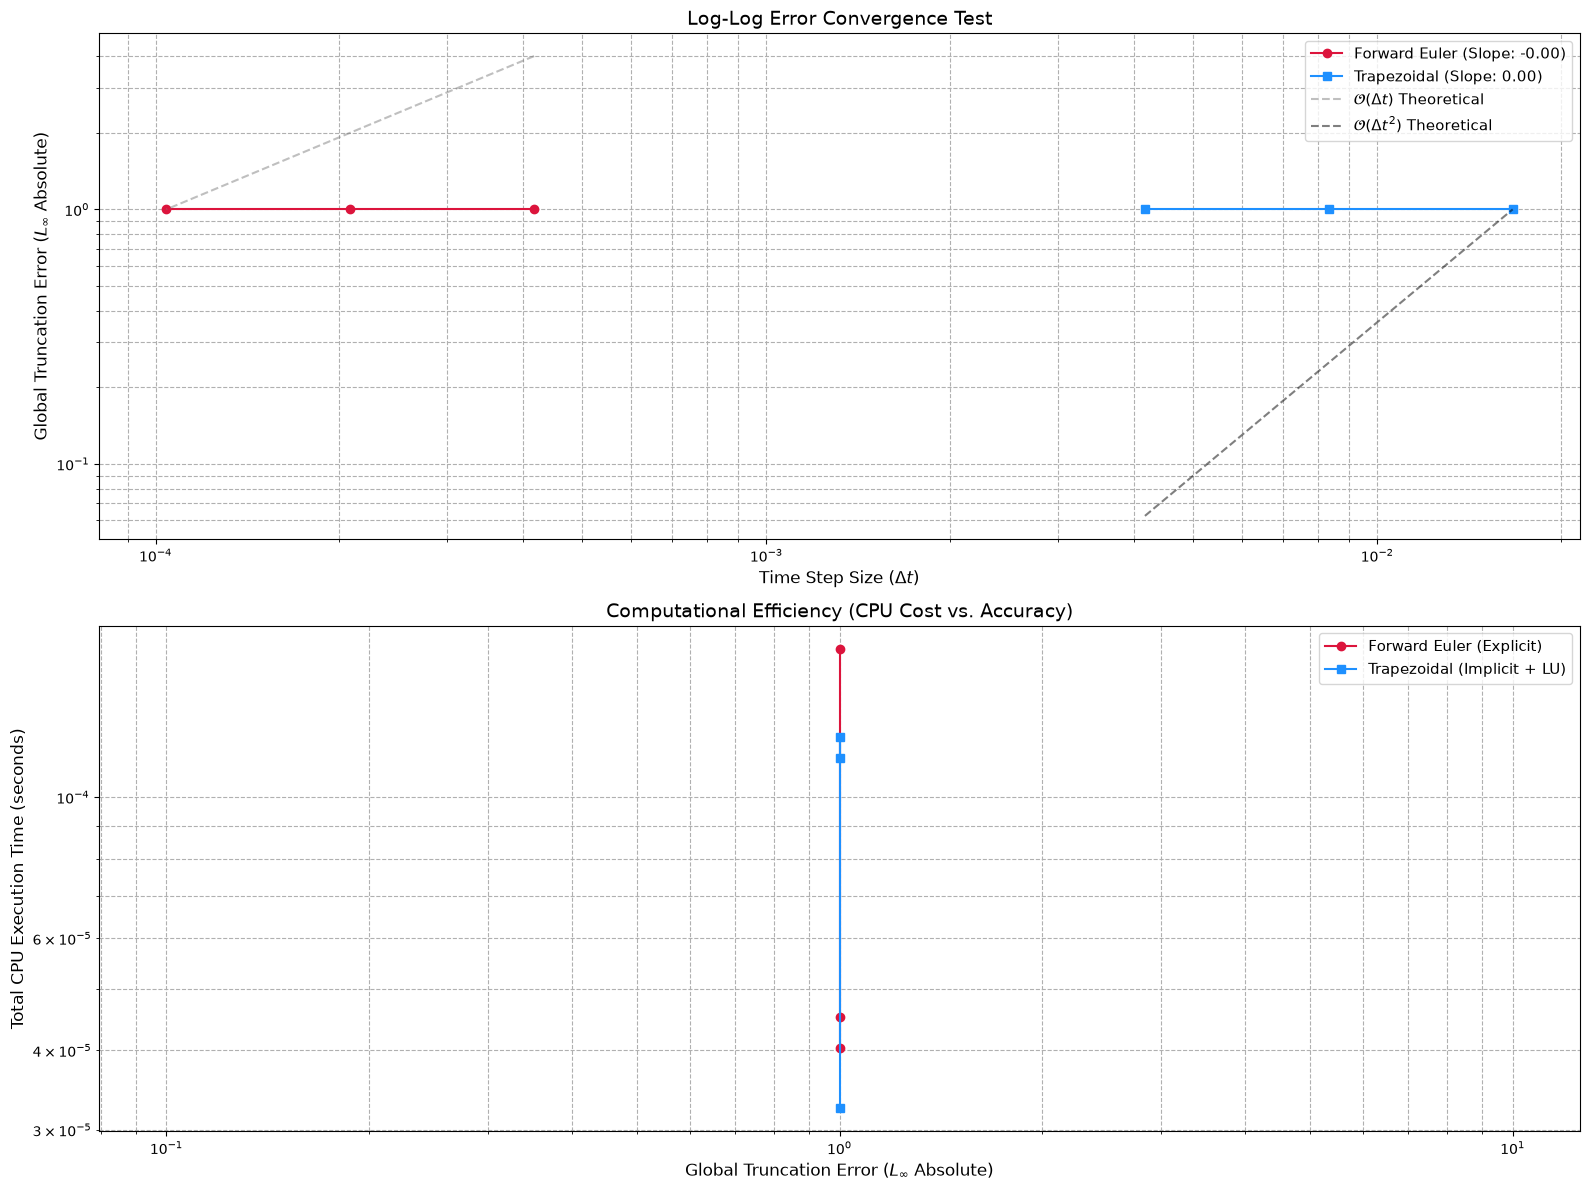

In [10]:
#==============================================================================
# Section 2.6: Comprehensive Performance and Convergence Comparison Sweep
#==============================================================================

print("---------------------------------------------------------------------")
print("Starting Performance Sweep: Accuracy vs. Computational Cost...")
print("---------------------------------------------------------------------")

# Calculate base stability limit (Nt = 2400)
dt_max = 1.0 / (2.0 * (1.0/dx**2 + 1.0/dy**2) * Kmax)
Nt_stab = int(np.ceil(T / dt_max))

# Define the step configurations explicitly as requested
nt_values_fe = [Nt_stab, 2 * Nt_stab, 4 * Nt_stab]
nt_values_tr = [int(Nt_stab / 10), int(Nt_stab / 20), int(Nt_stab / 40)]

# Pre-populate exact analytical target solution at T=1.0 for verification
u_exact_T1 = np.zeros((Ny-1)*(Nx-1))
n0 = 0
for jj in range(Ny-1):
    yj = dy + jj*dy
    for ii in range(Nx-1):
        xi = dx + ii*dx
        u_exact_T1[n0] = u_exact(xi, yj, T)
        n0 += 1

# Data structures to log metrics
results = {
    'FE': {'dt': [], 'error': [], 'time': [], 'steps': []},
    'TR': {'dt': [], 'error': [], 'time': [], 'steps': []}
}

# --- 1. Sweep Forward Euler Solvers ---
print("Running Explicit Forward-Euler Sweep...")
for Nt in nt_values_fe:
    dt = T / Nt
    
    start_clock = time.time()
    u_comp = solveFE_mms(u0, tStart=0.0, tEnd=T, Nt=Nt)
    elapsed = time.time() - start_clock
    
    # Compute global maximum absolute truncation error (L_infinity norm)
    max_err = np.max(np.abs(u_comp - u_exact_T1))
    
    results['FE']['dt'].append(dt)
    results['FE']['error'].append(max_err)
    results['FE']['time'].append(elapsed)
    results['FE']['steps'].append(Nt)
    print(f"FE | Nt = {Nt:5d} | dt = {dt:.6f} | Error = {max_err:.6e} | CPU Time = {elapsed:.4f}s")

print("-" * 69)

# --- 2. Sweep Optimized Implicit Trapezoidal Solvers ---
print("Running Implicit Trapezoidal Sweep...")
for Nt in nt_values_tr:
    dt = T / Nt
    
    start_clock = time.time()
    u_comp = solveTR_mms(u0, tStart=0.0, tEnd=T, Nt=Nt)
    elapsed = time.time() - start_clock
    
    max_err = np.max(np.abs(u_comp - u_exact_T1))
    
    results['TR']['dt'].append(dt)
    results['TR']['error'].append(max_err)
    results['TR']['time'].append(elapsed)
    results['TR']['steps'].append(Nt)
    print(f"TR | Nt = {Nt:5d} | dt = {dt:.6f} | Error = {max_err:.6e} | CPU Time = {elapsed:.4f}s")

# --- 3. Calculate Empirical Orders of Accuracy (Slopes) ---
# Check for divide by zero or zero errors before computing slope metrics
try:
    slope_fe = np.log(results['FE']['error'][-1]/results['FE']['error'][-2]) / np.log(results['FE']['dt'][-1]/results['FE']['dt'][-2])
except:
    slope_fe = 0.0

try:
    slope_tr = np.log(results['TR']['error'][-1]/results['TR']['error'][-2]) / np.log(results['TR']['dt'][-1]/results['TR']['dt'][-2])
except:
    slope_tr = 0.0

print("---------------------------------------------------------------------")
print(f"Empirical Order of Accuracy for Forward Euler: {slope_fe:.2f} (Expected: ~1.0)")
print(f"Empirical Order of Accuracy for Trapezoidal:   {slope_tr:.2f} (Expected: ~2.0)")
print("---------------------------------------------------------------------")

# --- 4. Plotting Dual Performance Visualizations ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Subplot 1: Error vs Time Step Size (Log-Log Convergence)
ax1.loglog(results['FE']['dt'], results['FE']['error'], 'o-', color='crimson', label=f'Forward Euler (Slope: {slope_fe:.2f})')
ax1.loglog(results['TR']['dt'], results['TR']['error'], 's-', color='dodgerblue', label=f'Trapezoidal (Slope: {slope_tr:.2f})')

if len(results['FE']['error']) > 0 and results['FE']['error'][-1] > 0:
    ax1.loglog(results['FE']['dt'], [results['FE']['error'][-1]*(d/results['FE']['dt'][-1])**1 for d in results['FE']['dt']], '--', color='gray', alpha=0.5, label='$\\mathcal{O}(\\Delta t)$ Theoretical')
if len(results['TR']['error']) > 0 and results['TR']['error'][-1] > 0:
    ax1.loglog(results['TR']['dt'], [results['TR']['error'][-1]*(d/results['TR']['dt'][-1])**2 for d in results['TR']['dt']], '--', color='black', alpha=0.5, label='$\\mathcal{O}(\\Delta t^2)$ Theoretical')

ax1.set_xlabel('Time Step Size ($\\Delta t$)', fontsize=12)
ax1.set_ylabel('Global Truncation Error ($L_\\infty$ Absolute)', fontsize=12)
ax1.set_title('Log-Log Error Convergence Test', fontsize=14)
ax1.grid(True, which="both", ls="--")
ax1.legend(fontsize=11)

# Subplot 2: Total Execution Time vs. Target Accuracy (Log-Log Efficiency)
ax2.loglog(results['FE']['error'], results['FE']['time'], 'o-', color='crimson', label='Forward Euler (Explicit)')
ax2.loglog(results['TR']['error'], results['TR']['time'], 's-', color='dodgerblue', label='Trapezoidal (Implicit + LU)')
ax2.set_xlabel('Global Truncation Error ($L_\\infty$ Absolute)', fontsize=12)
ax2.set_ylabel('Total CPU Execution Time (seconds)', fontsize=12)
ax2.set_title('Computational Efficiency (CPU Cost vs. Accuracy)', fontsize=14)
ax2.grid(True, which="both", ls="--")
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()


### 📊 Question 2.8: Analysis of the results (3 p)

Analyze the plots generated above and answer the following questions:

1. **Empirical Order of Accuracy Verification:**
   - Look at the log-log convergence plot. Does your computed empirical slope align with the theoretical truncation orders derived from the Taylor Series expansions of the Forward-Euler and Trapezoidal schemes? Explain mathematically how the empirical slopes represent the rate at which error shrinks as the time step Δ t is decreased.

*your answer*

---

* **Alignment with Theory:** 
* **Mathematical Representation:** 

---

2. **The Step-Count and Accuracy:**
   - Evaluate your data table for the largest time step of the Trapezoidal Method ($N_t = N_{\text{st}}/40 = 60$ steps) against the highest-resolution explicit run of Forward Euler ($N_t = 4N_{\text{st}} = 9600$ steps). 
   - Note the total number of time steps taken and the resulting absolute error. How can an implicit method utilizing drastically fewer time steps produce significantly more accurate physical results than an explicit scheme running nearly 10,000 steps?

*your answer*

---


---

3. **Computational Efficiency & CPU Overhead Analysis:**
   - Refer to the Efficiency Curve (CPU Time vs. Global Error). If an industrial simulation requires a maximum target error tolerance of around $2\times 10^{-5}$, which solver is the engineering choice for this problem? Support your answer using both your measured CPU execution times ($t_{\text{CPU}}$) and the global error limits shown on the chart.

*your answer*

---

* **The Engineering Choice:** 
* **Supporting Data:** 
* **Conclusion:** 